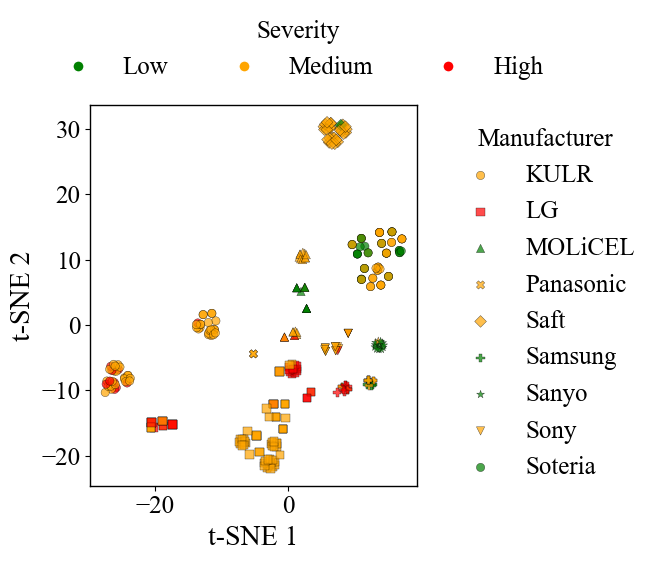

In [5]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.manifold import TSNE
import umap.umap_ as umap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ============================
# Load data
# ============================
df = pd.read_excel("data/dataframe_processed.xlsx")

# Features used as input (前 6 列)
X_raw = df.iloc[:, :6]

# Target
y = df["Severity"]
manufacturer = df["Manufacturer"]

# ============================
# One-hot encode categorical features
# ============================
encoder = OneHotEncoder()
X_encoded = encoder.fit_transform(X_raw)

# ============================
# Prepare labels for plotting
# ============================

colors = {
    "blue":  "#4C72B0",
    "green": "#55A868",
    "orange":"#CCB974",
    "red":   "#C44E52",
    "purple":"#8172B2"
    }
# Global font and plot settings
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "axes.linewidth": 1.0
})


severity_to_color = {
    "Low": "green",
    "Medium": "orange",
    "High": "red"
}

default_color = "gray"
colors = y.map(lambda s: severity_to_color.get(s, default_color))

manu_unique = manufacturer.unique()
markers = ["o", "s", "^", "X", "D", "P", "*", "v"]  # 至少 8 种 marker
manu_to_marker = {m: markers[i % len(markers)] for i, m in enumerate(manu_unique)}

# ============================
# 1) t-SNE Embedding
# ============================
tsne = TSNE(
    n_components=2,
    learning_rate="auto",
    init="random",
    perplexity=30,
    random_state=42
)
X_tsne = tsne.fit_transform(X_encoded)



fig, ax = plt.subplots(figsize=(7, 5))

# --- scatter ---
for manu in manu_unique:
    idx = (manufacturer == manu)
    ax.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        c=colors[idx],
        marker=manu_to_marker[manu],
        alpha=0.7,
        label=manu,
        edgecolor="k",
        linewidth=0.3,
    )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# --- Legend 1：Manufacturer ---
ax.legend(
    title="Manufacturer",
    loc="upper left",
    bbox_to_anchor=(1.05, 1),
    frameon=False
)

# --- Legend 2：Severity ---
from matplotlib.lines import Line2D

severity_legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=sev, markerfacecolor=col, markersize=8)
    for sev, col in severity_to_color.items()
]

fig.legend(
    handles=severity_legend_elements,
    title="Severity",
    loc="lower center",
    bbox_to_anchor=(0.45, 0.95),
    ncol=len(severity_legend_elements),
    frameon=False
)


plt.tight_layout()
plt.savefig("imgs/plot/t-SNE Embedding of Battery Cell Features.png", dpi=600, bbox_inches="tight")
plt.show()


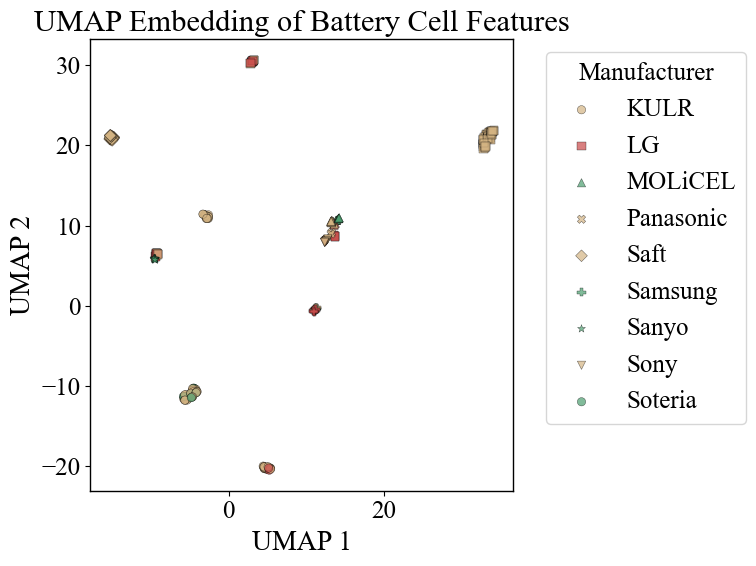

In [4]:

# ============================
# 2) UMAP Embedding
# ============================
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)
X_umap = umap_model.fit_transform(X_encoded)

plt.figure(figsize=(8, 6))
for manu in manu_unique:
    idx = (manufacturer == manu)
    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        c=colors[idx],
        marker=manu_to_marker[manu],
        alpha=0.7,
        label=manu,
        edgecolor="k",
        linewidth=0.3,
    )

plt.title("UMAP Embedding of Battery Cell Features")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Manufacturer", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("imgs/plot/UMAP Embedding of Battery Cell Features.png", dpi=600, bbox_inches="tight")
plt.show()
